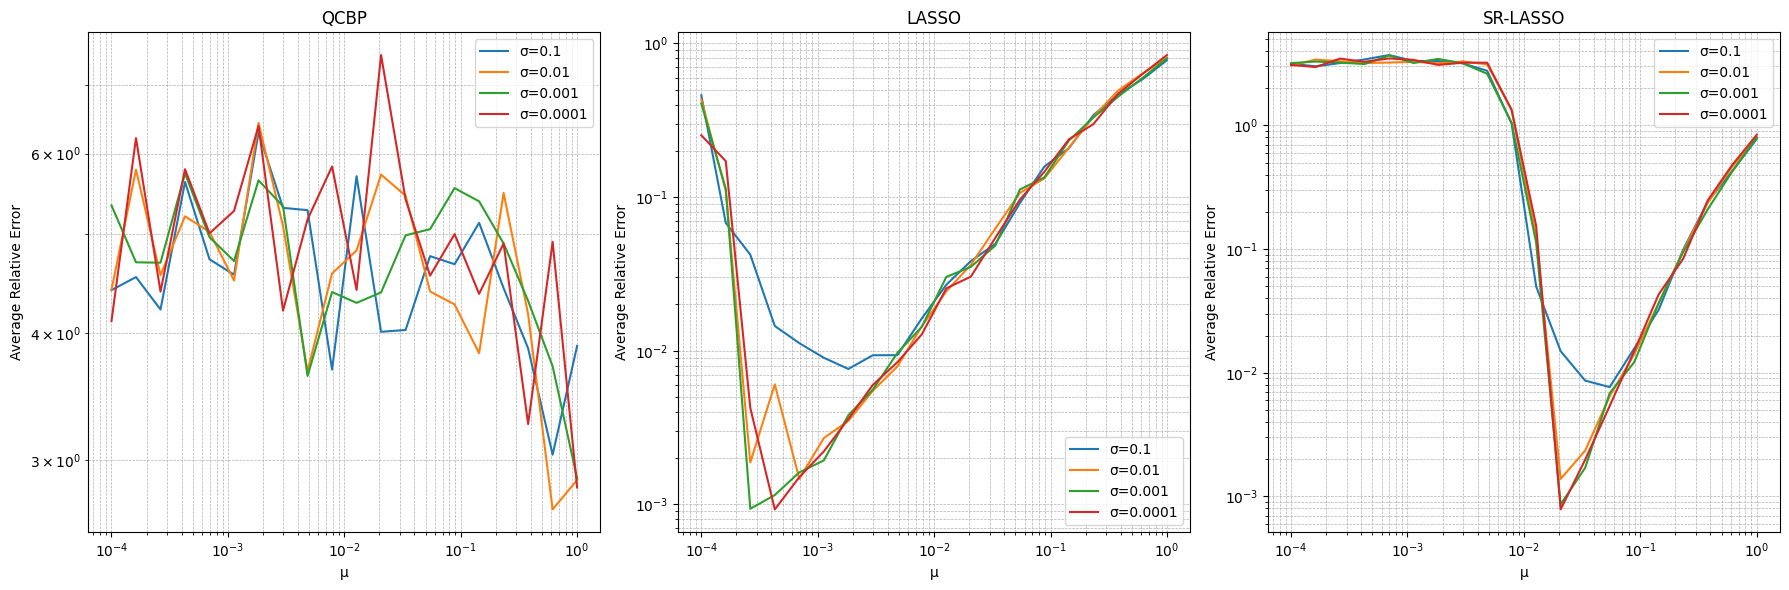

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from scipy.optimize import linprog

# Set the parameters
n = 128
T = 10
s = 10
m = 60
sigma_values = [10**-1, 10**-2, 10**-3, 10**-4]
mu_values = np.logspace(-4, 0, 20)  # Example range for mu

# Function to generate a random s-sparse vector
def generate_sparse_vector(n, s):
    x = np.zeros(n)
    indices = np.random.choice(n, s, replace=False)
    x[indices] = np.random.randn(s)
    return x

# Function to solve QCBP
def solve_qcbp(A, b, mu):
    c = np.concatenate([np.zeros(n), np.ones(m)])
    G = np.concatenate([np.hstack([A, -np.eye(m)]), np.hstack([-A, -np.eye(m)])])
    h = np.concatenate([b + mu, -b + mu])
    bounds = [(None, None)] * n + [(0, None)] * m
    result = linprog(c, A_ub=G, b_ub=h, bounds=bounds, method='highs')
    return result.x[:n]

# Function to solve LASSO
def solve_lasso(A, b, mu):
    lasso = Lasso(alpha=mu, fit_intercept=False, max_iter=10000)
    lasso.fit(A, b)
    return lasso.coef_

# Function to solve SR-LASSO (Squared Residuals LASSO)
def solve_sr_lasso(A, b, mu):
    lasso = Lasso(alpha=mu**2, fit_intercept=False, max_iter=10000)
    lasso.fit(A, b)
    return lasso.coef_

# Function to add noise
def add_noise(A, x_true, sigma):
    e = np.random.randn(m)
    e /= np.linalg.norm(e, 2)
    b = A @ x_true + sigma * e
    return b

# Initialize dictionaries to store results
errors_qcbp = {sigma: [] for sigma in sigma_values}
errors_lasso = {sigma: [] for sigma in sigma_values}
errors_sr_lasso = {sigma: [] for sigma in sigma_values}

# Loop over sigma values
for sigma in sigma_values:
    for mu in mu_values:
        avg_error_qcbp = 0
        avg_error_lasso = 0
        avg_error_sr_lasso = 0
        for t in range(T):
            # Generate a random s-sparse vector and matrix
            x_true = generate_sparse_vector(n, s)
            A = np.random.randn(m, n)
            
            # Add noise to the measurements
            b = add_noise(A, x_true, sigma)
            
            # Solve QCBP
            x_qcbp = solve_qcbp(A, b, mu)
            error_qcbp = np.linalg.norm(x_true - x_qcbp, 1) / np.linalg.norm(x_true, 1)
            avg_error_qcbp += error_qcbp
            
            # Solve LASSO
            x_lasso = solve_lasso(A, b, mu)
            error_lasso = np.linalg.norm(x_true - x_lasso, 1) / np.linalg.norm(x_true, 1)
            avg_error_lasso += error_lasso
            
            # Solve SR-LASSO
            x_sr_lasso = solve_sr_lasso(A, b, mu)
            error_sr_lasso = np.linalg.norm(x_true - x_sr_lasso, 1) / np.linalg.norm(x_true, 1)
            avg_error_sr_lasso += error_sr_lasso
        
        # Average errors over T trials
        avg_error_qcbp /= T
        avg_error_lasso /= T
        avg_error_sr_lasso /= T
        
        # Store the results
        errors_qcbp[sigma].append(avg_error_qcbp)
        errors_lasso[sigma].append(avg_error_lasso)
        errors_sr_lasso[sigma].append(avg_error_sr_lasso)

# Plot the results
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
for sigma in sigma_values:
    ax[0].plot(mu_values, errors_qcbp[sigma], label=f'σ={sigma}')
    ax[1].plot(mu_values, errors_lasso[sigma], label=f'σ={sigma}')
    ax[2].plot(mu_values, errors_sr_lasso[sigma], label=f'σ={sigma}')

for i, method in enumerate(['QCBP', 'LASSO', 'SR-LASSO']):
    ax[i].set_xscale('log')
    ax[i].set_yscale('log')
    ax[i].set_xlabel('μ')
    ax[i].set_ylabel('Average Relative Error')
    ax[i].set_title(method)
    ax[i].legend()
    ax[i].grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()


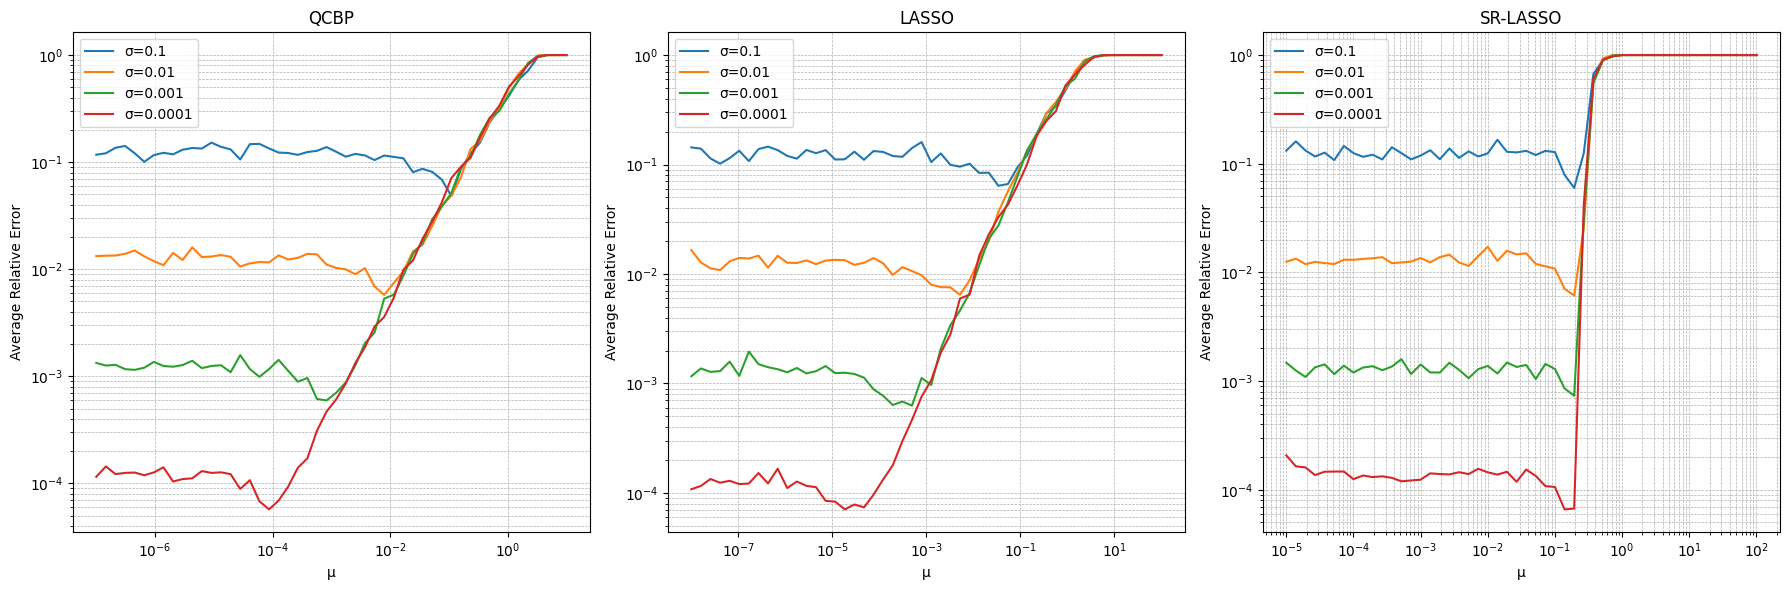

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp

# Set parameters
n = 128
T = 10
s = 10
m = 60
sigma_values = [10**-1, 10**-2, 10**-3, 10**-4]
gridsize = 50
mu_values_QCBP = 10**np.linspace(-7, 1, gridsize)
mu_values_LASSO = 10**np.linspace(-8, 2, gridsize)
mu_values_SR_LASSO = 10**np.linspace(-5, 2, gridsize)

# Function to generate a random s-sparse vector
def generate_sparse_vector(n, s):
    x = np.zeros(n)
    indices = np.random.choice(n, s, replace=False)
    x[indices] = np.random.randn(s)
    return x

# Function to add noise
def add_noise(A, x_true, sigma):
    e = np.random.randn(m)
    e /= np.linalg.norm(e, 2)
    b = A @ x_true + sigma * e
    return b

# Initialize dictionaries to store results
errors_qcbp = {sigma: [] for sigma in sigma_values}
errors_lasso = {sigma: [] for sigma in sigma_values}
errors_sr_lasso = {sigma: [] for sigma in sigma_values}

# Loop over sigma values
for sigma in sigma_values:
    for mu in mu_values_QCBP:
        avg_error_qcbp = 0
        for t in range(T):
            x_true = generate_sparse_vector(n, s)
            A = np.random.randn(m, n) / np.sqrt(m)
            b = add_noise(A, x_true, sigma)
            
            # Solve QCBP
            z_qcbp = cp.Variable(n)
            objective_qcbp = cp.Minimize(cp.norm(z_qcbp, 1))
            constraints_qcbp = [cp.norm(A @ z_qcbp - b, 2) <= mu]
            prob_qcbp = cp.Problem(objective_qcbp, constraints_qcbp)
            prob_qcbp.solve()
            x_qcbp = z_qcbp.value
            error_qcbp = np.linalg.norm(x_true - x_qcbp, 1) / np.linalg.norm(x_true, 1)
            avg_error_qcbp += error_qcbp
        avg_error_qcbp /= T
        errors_qcbp[sigma].append(avg_error_qcbp)

    for mu in mu_values_LASSO:
        avg_error_lasso = 0
        for t in range(T):
            x_true = generate_sparse_vector(n, s)
            A = np.random.randn(m, n) / np.sqrt(m)
            b = add_noise(A, x_true, sigma)
            
            # Solve LASSO
            z_lasso = cp.Variable(n)
            objective_lasso = cp.Minimize(mu * cp.norm(z_lasso, 1) + cp.norm2(A @ z_lasso - b)**2)
            prob_lasso = cp.Problem(objective_lasso)
            prob_lasso.solve()
            x_lasso = z_lasso.value
            error_lasso = np.linalg.norm(x_true - x_lasso, 1) / np.linalg.norm(x_true, 1)
            avg_error_lasso += error_lasso
        avg_error_lasso /= T
        errors_lasso[sigma].append(avg_error_lasso)

    for mu in mu_values_SR_LASSO:
        avg_error_sr_lasso = 0
        for t in range(T):
            x_true = generate_sparse_vector(n, s)
            A = np.random.randn(m, n) / np.sqrt(m)
            b = add_noise(A, x_true, sigma)
            
            # Solve SR-LASSO
            z_sr_lasso = cp.Variable(n)
            objective_sr_lasso = cp.Minimize(mu * cp.norm(z_sr_lasso, 1) + cp.norm(A @ z_sr_lasso - b, 2))
            prob_sr_lasso = cp.Problem(objective_sr_lasso)
            prob_sr_lasso.solve()
            x_sr_lasso = z_sr_lasso.value
            error_sr_lasso = np.linalg.norm(x_true - x_sr_lasso, 1) / np.linalg.norm(x_true, 1)
            avg_error_sr_lasso += error_sr_lasso
        avg_error_sr_lasso /= T
        errors_sr_lasso[sigma].append(avg_error_sr_lasso)

# Plot the results
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
for sigma in sigma_values:
    ax[0].plot(mu_values_QCBP, errors_qcbp[sigma], label=f'σ={sigma}')
    ax[1].plot(mu_values_LASSO, errors_lasso[sigma], label=f'σ={sigma}')
    ax[2].plot(mu_values_SR_LASSO, errors_sr_lasso[sigma], label=f'σ={sigma}')

for i, method in enumerate(['QCBP', 'LASSO', 'SR-LASSO']):
    ax[i].set_xscale('log')
    ax[i].set_yscale('log')
    ax[i].set_xlabel('μ')
    ax[i].set_ylabel('Average Relative Error')
    ax[i].set_title(method)
    ax[i].legend()
    ax[i].grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()
